In [1]:
import pandas as pd
df = pd.read_csv('New_York_City_Population_By_Neighborhood_Tabulation_Areas_20240618.csv')

In [2]:
import geopandas as gpd
gdf = gpd.read_file('2010 Neighborhood Tabulation Areas (NTAs).geojson')

In [4]:
gdf_merged = gdf.merge(df, right_on = 'NTA Code',left_on = 'ntacode')

In [7]:
gdf_merged.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2000,47,BK50,Canarsie,85058


In [10]:
gdf_manhattan = gdf_merged[gdf_merged.boro_name=='Manhattan']
gdf_manhattan

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
90,MN19,17390168.1386,061,Turtle Bay-East Midtown,21251.8414488,Manhattan,1,"MULTIPOLYGON (((-73.96052 40.74411, -73.96057 ...",Manhattan,2000,61,MN19,Turtle Bay-East Midtown,49737
91,MN19,17390168.1386,061,Turtle Bay-East Midtown,21251.8414488,Manhattan,1,"MULTIPOLYGON (((-73.96052 40.74411, -73.96057 ...",Manhattan,2010,61,MN19,Turtle Bay-East Midtown,51231
94,MN04,15984383.0261,061,Hamilton Heights,17103.3632867,Manhattan,1,"MULTIPOLYGON (((-73.94035 40.83046, -73.94014 ...",Manhattan,2000,61,MN04,Hamilton Heights,50555
95,MN04,15984383.0261,061,Hamilton Heights,17103.3632867,Manhattan,1,"MULTIPOLYGON (((-73.94035 40.83046, -73.94014 ...",Manhattan,2010,61,MN04,Hamilton Heights,48520
96,MN50,5575563.18924,061,Stuyvesant Town-Cooper Village,11061.8187289,Manhattan,1,"MULTIPOLYGON (((-73.96237 40.72421, -73.96201 ...",Manhattan,2000,61,MN50,Stuyvesant Town-Cooper Village,19101
97,MN50,5575563.18924,061,Stuyvesant Town-Cooper Village,11061.8187289,Manhattan,1,"MULTIPOLYGON (((-73.96237 40.72421, -73.96201 ...",Manhattan,2010,61,MN50,Stuyvesant Town-Cooper Village,21049
106,MN36,23127085.735,061,Washington Heights South,22143.3421167,Manhattan,1,"MULTIPOLYGON (((-73.93139 40.84743, -73.93185 ...",Manhattan,2000,61,MN36,Washington Heights South,93671
107,MN36,23127085.735,061,Washington Heights South,22143.3421167,Manhattan,1,"MULTIPOLYGON (((-73.93139 40.84743, -73.93185 ...",Manhattan,2010,61,MN36,Washington Heights South,84438
108,MN34,24494917.0275,061,East Harlem North,30603.6946289,Manhattan,1,"MULTIPOLYGON (((-73.92719 40.79735, -73.92735 ...",Manhattan,2000,61,MN34,East Harlem North,57148
109,MN34,24494917.0275,061,East Harlem North,30603.6946289,Manhattan,1,"MULTIPOLYGON (((-73.92719 40.79735, -73.92735 ...",Manhattan,2010,61,MN34,East Harlem North,58019


In [11]:
gdf_manhattan_local = gdf_manhattan.to_crs(2263)
gdf_merged = gdf_merged.to_crs(2263)

<Axes: >

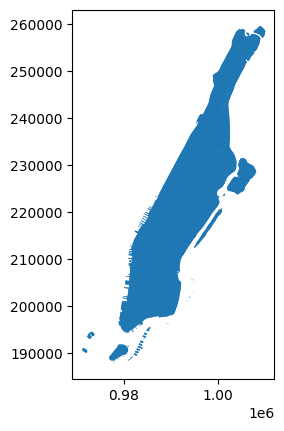

In [12]:
gdf_manhattan_local.plot()

In [13]:
distances = [100,1000,5000,10000 ,25000,100000]

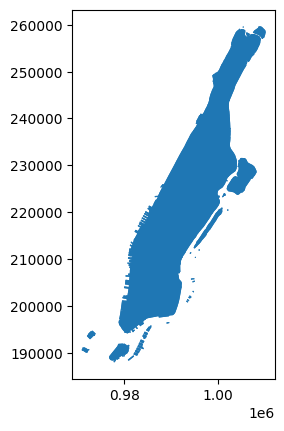

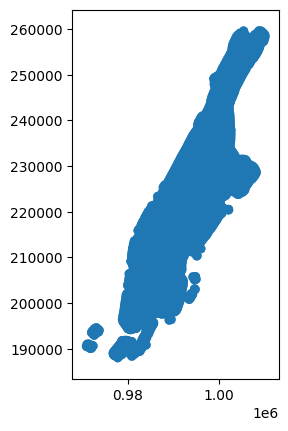

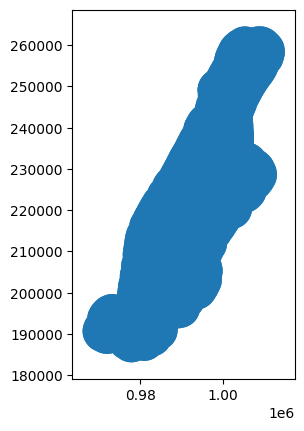

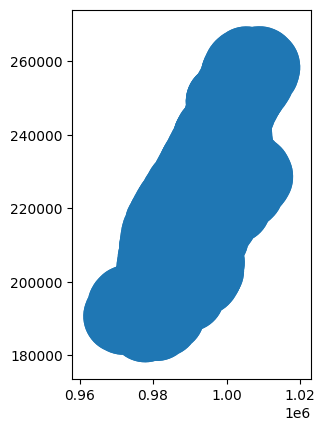

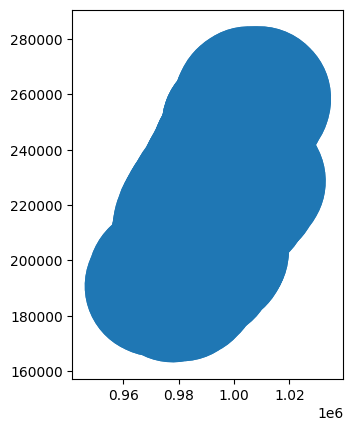

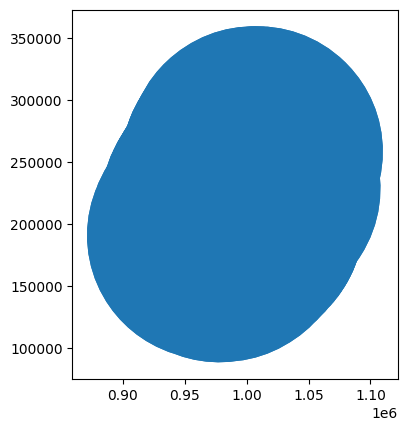

In [16]:
for distance in distances:
    gdf_manhattan_local.buffer(distance).plot()

<Axes: >

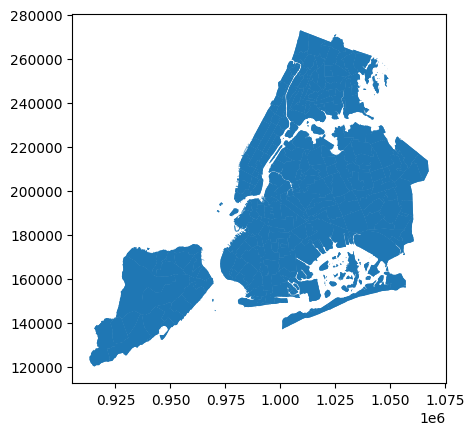

In [18]:
gdf_merged.plot()

In [21]:
gdf_merged_local_points = gdf_merged.copy()
gdf_merged_local_points['geometry'] = [g.centroid for g in list(gdf_merged_local_points.geometry)]
gdf_merged_local_points.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2000,81,QN08,St. Albans,50046
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2010,81,QN08,St. Albans,48593
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,POINT (1012073.055 171748.235),Brooklyn,2000,47,BK50,Canarsie,85058


<Axes: >

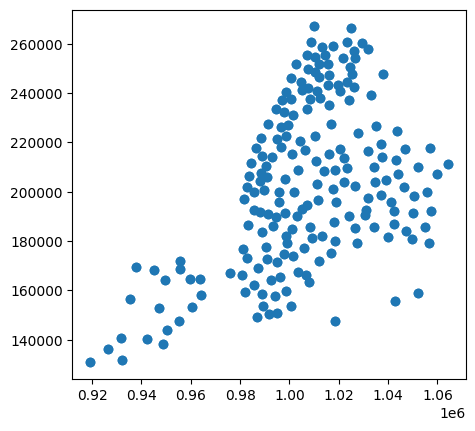

In [22]:
gdf_merged_local_points.plot()

<Axes: >

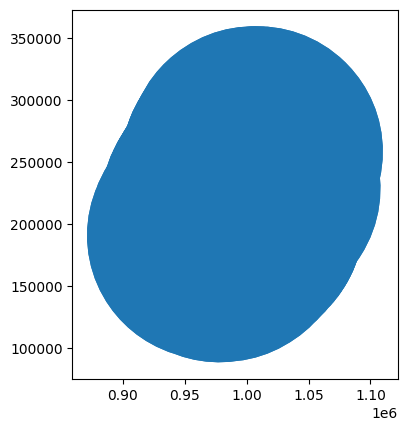

In [24]:
# buffering

distance = 100000

gdf_manhattan_local_buffered = gdf_manhattan_local.copy()
gdf_manhattan_local_buffered['geometry'] = gdf_manhattan_local_buffered['geometry'].buffer(distance)
gdf_manhattan_local_buffered.plot()

<Axes: >

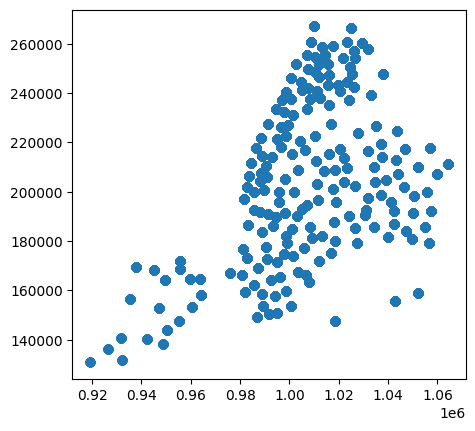

In [25]:
# spatial join

gdf_joined = gpd.sjoin(gdf_merged_local_points,gdf_manhattan_local_buffered)
gdf_joined.plot()

In [26]:
gdf_joined.head(3)

,ntacode_left,shape_area_left,county_fips_left,ntaname_left,shape_leng_left,boro_name_left,boro_code_left,geometry,Borough_left,Year_left,...,ntaname_right,shape_leng_right,boro_name_right,boro_code_right,Borough_right,Year_right,FIPS County Code_right,NTA Code_right,NTA Name_right,Population_right
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2000,...,Battery Park City-Lower Manhattan,43727.7254838,Manhattan,1,Manhattan,2000,61,MN25,Battery Park City-Lower Manhattan,20088
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2000,...,Battery Park City-Lower Manhattan,43727.7254838,Manhattan,1,Manhattan,2010,61,MN25,Battery Park City-Lower Manhattan,39699
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2000,...,Chinatown,20786.2546133,Manhattan,1,Manhattan,2000,61,MN27,Chinatown,52375


In [29]:
# compute popluation
print('Manhatan population: ', sum(gdf_joined.Population_left))
print('Buffer zone population: ', sum(gdf_joined.Population_right))
print('Population ratio: ', round(sum(gdf_joined.Population_left) / sum(gdf_joined.Population_right),2))

Manhatan population:  926925590
Buffer zone population:  1189058898
Population ratio:  0.78


In [30]:
def count_population_stats(distance):

    #buffering
    gdf_manhattan_local_buffered = gdf_manhattan_local.copy()
    gdf_manhattan_local_buffered['geometry'] = gdf_manhattan_local_buffered['geometry'].buffer(distance)
    gdf_manhattan_local_buffered.plot()

    #spatial join
    gdf_joined = gpd.sjoin(gdf_merged_local_points,gdf_manhattan_local_buffered)

    #compute population
    print('Zone Size: ', distance,' feet')
    print('Manhatan population: ', sum(gdf_joined.Population_left))
    print('Buffer zone population: ', sum(gdf_joined.Population_right))
    print('Population ratio: ', round(sum(gdf_joined.Population_left) / sum(gdf_joined.Population_right),2))
    print()

In [31]:
distances

[100, 1000, 5000, 10000, 25000, 100000]

Zone Size:  100  feet
Manhatan population:  6246136
Buffer zone population:  6468716
Population ratio:  0.97

Zone Size:  1000  feet
Manhatan population:  7073634
Buffer zone population:  7745976
Population ratio:  0.91

Zone Size:  5000  feet
Manhatan population:  45086628
Buffer zone population:  45091396
Population ratio:  1.0

Zone Size:  10000  feet
Manhatan population:  96690452
Buffer zone population:  99897392
Population ratio:  0.97

Zone Size:  25000  feet
Manhatan population:  283775832
Buffer zone population:  312385952
Population ratio:  0.91

Zone Size:  100000  feet
Manhatan population:  926925590
Buffer zone population:  1189058898
Population ratio:  0.78



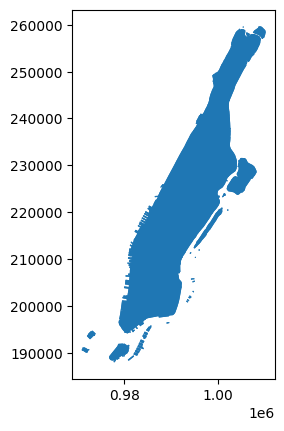

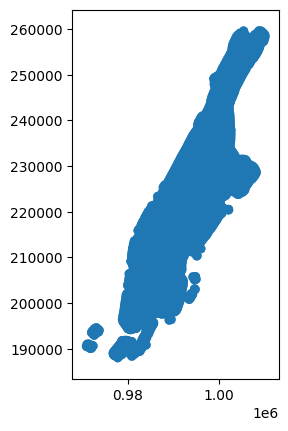

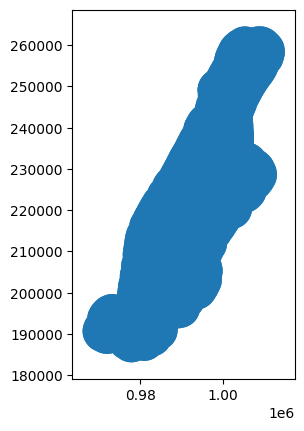

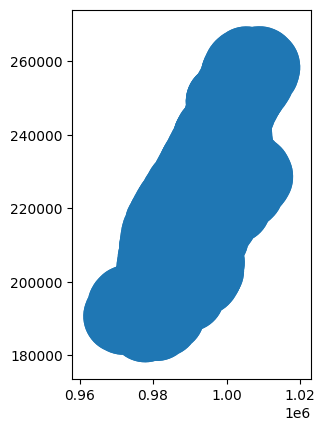

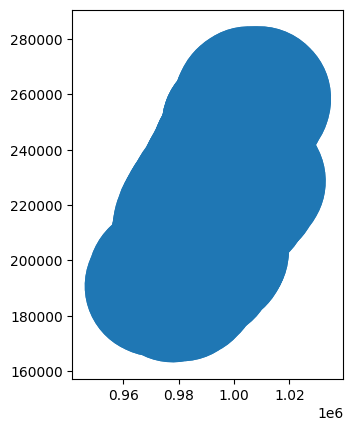

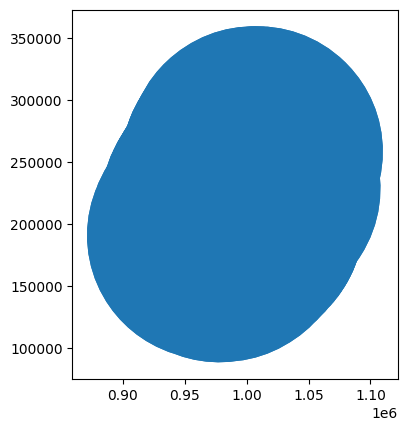

In [32]:
for distance in distances:
     count_population_stats(distance)